# Problem 1: Snakes and Ladders

This system is modeled as an absorbing Markov chain.

**State Space:**

$$
S=\{1,2,4,5,6,7,8,9,10,11,12,14,16,18,19,20\}
$$

**Absorbing State:**

$$
20
$$

We want to calculate the expected number of rolls needed to reach the absorbing state starting from square 1.

## 1. Setup and Initialization

We import `sympy` to perform exact symbolic matrix operations and enable pretty printing.

In [27]:
import sympy as sp
sp.init_printing()

We define the rational number $1/6$ representing the probability of rolling a standard 6-sided die, allowing exact analytical calculations.

In [28]:
s = sp.Rational(1, 6)

## 2. Transition Matrix Definition

It is important to note that we only include states that a player can occupy after a roll (i.e., valid landing positions after resolving any snakes or ladders).

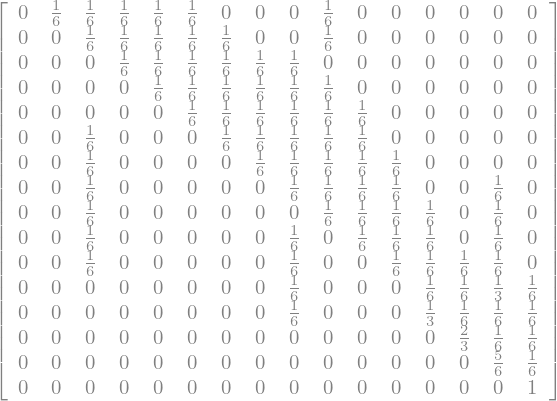

In [29]:
A = sp.Matrix([
# Square 1    
[0, s, s, s, s, s, 0, 0, 0, s, 0, 0, 0, 0, 0, 0],
# Square 2
[0, 0, s, s, s, s, s, 0, 0, s, 0, 0, 0, 0, 0, 0],
# Square 4
[0, 0, 0, s, s, s, s, s, s, 0, 0, 0, 0, 0, 0, 0],
# Square 5
[0, 0, 0, 0, s, s, s, s, s, s, 0, 0, 0, 0, 0, 0],
# Square 6
[0, 0, 0, 0, 0, s, s, s, s, s, s, 0, 0, 0, 0, 0],
# Square 7
[0, 0, s, 0, 0, 0, s, s, s, s, s, 0, 0, 0, 0, 0],
# Square 8
[0, 0, s, 0, 0, 0, 0, s, s, s, s, s, 0, 0, 0, 0],
# Square 9
[0, 0, s, 0, 0, 0, 0, 0, s, s, s, s, 0, 0, s, 0],
# Square 10
[0, 0, s, 0, 0, 0, 0, 0, 0, s, s, s, s, 0, s, 0],
# Square 11
[0, 0, s, 0, 0, 0, 0, 0, s, 0, s, s, s, 0, s, 0],
# Square 12
[0, 0, s, 0, 0, 0, 0, 0, s, 0, 0, s, s, s, s, 0],
# Square 14
[0, 0, 0, 0, 0, 0, 0, 0, s, 0, 0, 0, s, s, 2*s, s],
# Square 16
[0, 0, 0, 0, 0, 0, 0, 0, s, 0, 0, 0, 2*s, s, s, s],
# Square 18
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4*s, s, s],
# Square 19
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5*s, s],
# Square 20
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
])
A

Matrix $A$ is of size $16 \times 16$.

In [30]:
A.shape

## 3. Extracting the Transient Submatrix $Q$

We isolate the submatrix $Q$, retaining only the rows and columns corresponding to transient states (the first 15 states).

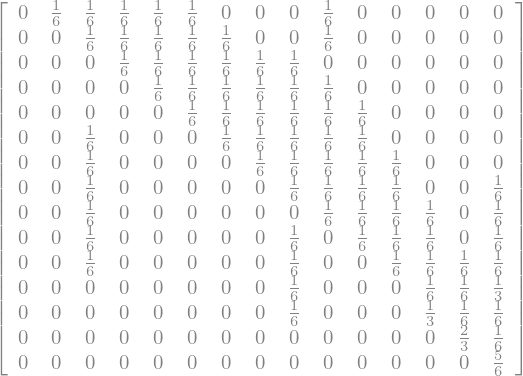

In [31]:
Q = A[:-1, :-1]
Q

Since Square 20 is the sole absorbing state, $Q$ is a $15 \times 15$ matrix.

In [32]:
Q.shape

## 4. Fundamental Matrix Construction

We create an identity matrix $I$ of the same dimension as $Q$.

In [33]:
I = sp.eye(Q.rows)

We calculate the matrix $(I - Q)$.

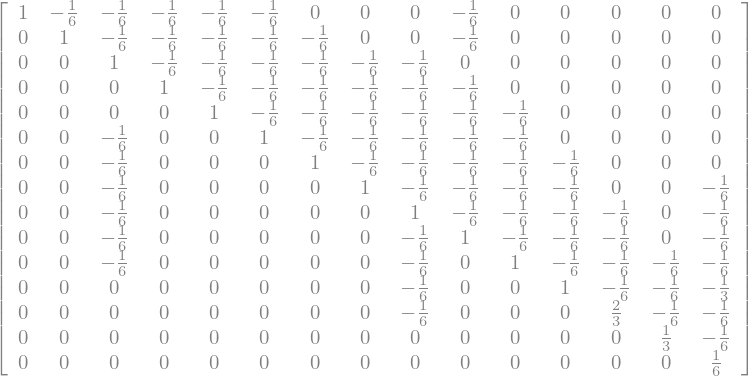

In [34]:
IQ = I - Q
IQ

## 5. Computing the Fundamental Matrix $N$

We compute the Fundamental Matrix $N = (I - Q)^{-1}$. Each element $N_{i,j}$ gives the expected number of visits to transient state $j$ starting from transient state $i$.

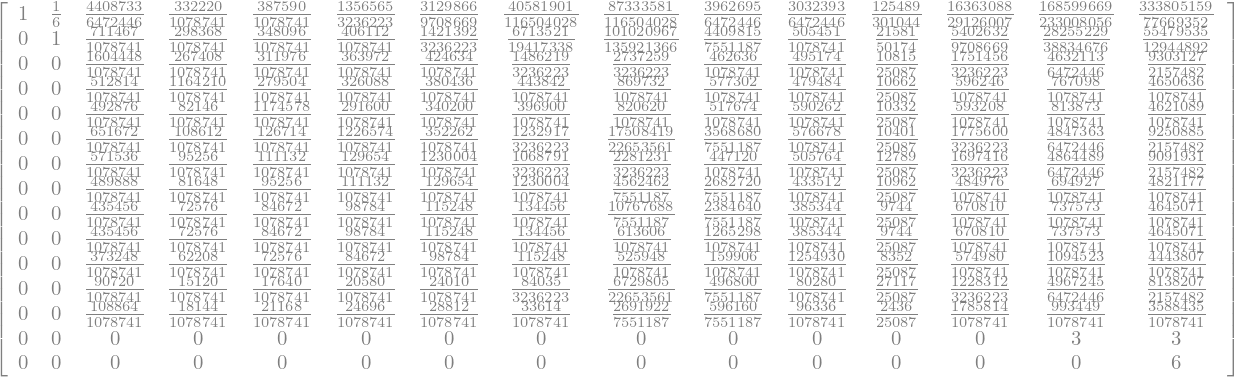

In [35]:
N = IQ.inv()
N

## 6. Expected Number of Rolls to Reach Absorption

The total expected number of rolls to reach the absorbing state starting from transient state $i$ is obtained by summing all entries in the $i$-th row of the fundamental matrix $N$.

Starting from Square 1 (row index 0):

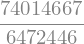

In [36]:
expected_rolls = sum(N[0, :])
expected_rolls

Finally, we evaluate this exact fraction numerically to get the floating-point approximation.

In [37]:
expected_rolls.evalf()

## 7. Monte Carlo Simulation Verification

To validate our analytical result, we run a Monte Carlo simulation of the Markov chain across a large number of trials.

In [38]:
import numpy as np

# Convert symbolic transition matrix A to a NumPy floating-point array
P = np.array(A.tolist(), dtype=float)

def simulate_game(P, start_state=0, absorbing_state=15):
    current_state = start_state
    steps = 0
    while current_state != absorbing_state:
        current_state = np.random.choice(P.shape[1], p=P[current_state])
        steps += 1
    return steps

# Run 100,000 simulations
num_simulations = 100000
simulated_steps = [simulate_game(P) for _ in range(num_simulations)]

mc_mean = np.mean(simulated_steps)

print(f"Analytical Expected Rolls: {float(expected_rolls.evalf()):.4f}")
print(f"Monte Carlo Mean ({num_simulations:,} runs): {mc_mean:.4f} ")

Analytical Expected Rolls: 11.4353
Monte Carlo Mean (100,000 runs): 11.4118 
